## Demonstration of individual Ovenbird classification method

This notebook demonstrates the use of a machine learning model we developed for discriminating individual Ovenbirds' songs. We load the model from a checkpoint included in this repository, and use it to generate feature sets for 10 songs from each of 10 individuals, using the sample data also included in this repository. 

For code to reproduce the methodology, experiments, and results of our manuscript see the README file and `scripts` directory.

In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.autonotebook import tqdm
import opensoundscape as opso
import tuftelike

from matplotlib import pyplot as plt
def figsize(w,h):
    plt.rcParams['figure.figsize']=[w,h]
figsize(15,5) #for big visuals
%config InlineBackend.figure_format = 'retina'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# gill sans
# plt.rcParams['font.family'] = 'Gill Sans'

import torch
def identity(x):
    return x

# local source code imports
import sys
sys.path.append(f'./src/')
import evaluation
from evaluation import evaluate, mean_range_table
from preprocessor import OvenbirdPreprocessor
import random
from model import Resnet18_Classifier, ContrastiveResnet18, load_ovenbird_model


palette = sns.color_palette("deep") + sns.color_palette("Dark2")

# set seed for reproducibility
random.seed(2024)
np.random.seed(2024)
metrics_list = ["accuracy", "ari", "nmi", "fmi", "v_measure"]

import seaborn as sns

/var/folders/d8/265wdp1n0bn_r85dh3pp95fh0000gq/T/ipykernel_90595/36424810.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/Users/SML161/miniconda3/envs/opso0120/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/Users/SML161/miniconda3/envs/opso0120/lib/python3.11/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


### Load sample dataset of individual Ovenbird songs
We provide a small sample dataset of 10 songs from each of 10 individual Ovenbirds in this repository for demonstration purposes. 

The full annotated set of Ovenbird recordings is available on Environmental Data Initiative, and the set of Ovenbird songs used for a 5-year 126-site capture-recapture analysis from passive acoustic monitoring data is available in a separate dataset. This notebook makes use of the included sample dataset. 

The `labeled_clips_sample.csv` the `sample_data` folder contains metadata for the sample dataset, including:
- `localization_event_id`: unique identifier for each Ovenbird singing event
- `array`: the identity of an acoustic localization array from Alberta, Canada
- `clip_name`: file name of a 10-second audio clip, of which seconds 4-6 are an Ovenbird song detection
- 


In [2]:
audio_clip_table = pd.read_csv("./sample_data/labeled_clips_sample.csv").set_index(
    ["file", "start_time", "end_time"]
)
print(f"Number of audio clips: {audio_clip_table.index.nunique()}")

Number of audio clips: 100


### Use the Ovenbird feature extractor to generate feature sets for each song
This machine learning model takes as input paths to audio clips, and returns feature vectors that provide discrimination between individual Ovenbirds based on acoustic characteristics. 

In [10]:
cnn = load_ovenbird_model()
emb = cnn.embed(audio_clip_table)
print(f"generated embeddings for {len(emb)} audio clips, output shape: {emb.shape}")

# reduce embeddings to 2d with TSNE
emb_2d = evaluation.reduce_dims(
    emb.values, reduction_algorithm="tsne", reduced_n_dimensions=2
)

  0%|          | 0/100 [00:00<?, ?it/s]

/Users/SML161/miniconda3/envs/opso0120/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


generated embeddings for 100 audio clips, output shape: (100, 512)


### Visualize embeddings for each individual

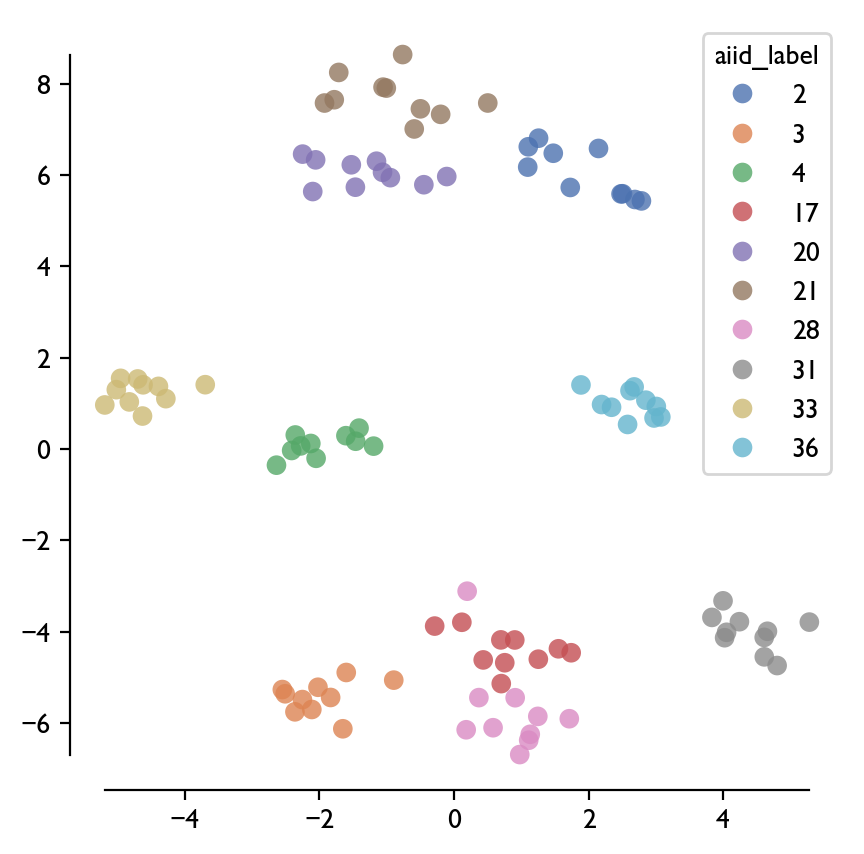

In [20]:
figsize(5, 5)
fig = sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=audio_clip_table.aiid_label,
    palette=palette[:10],
    s=50,
    alpha=0.8,
    edgecolor="none",
)
tuftelike._remove_chart_junk(ax=fig.axes, xs=emb_2d[:, 0], ys=emb_2d[:, 1])

## Inspect some of the songs' spectrograms and audio clips

Individual ID: 20


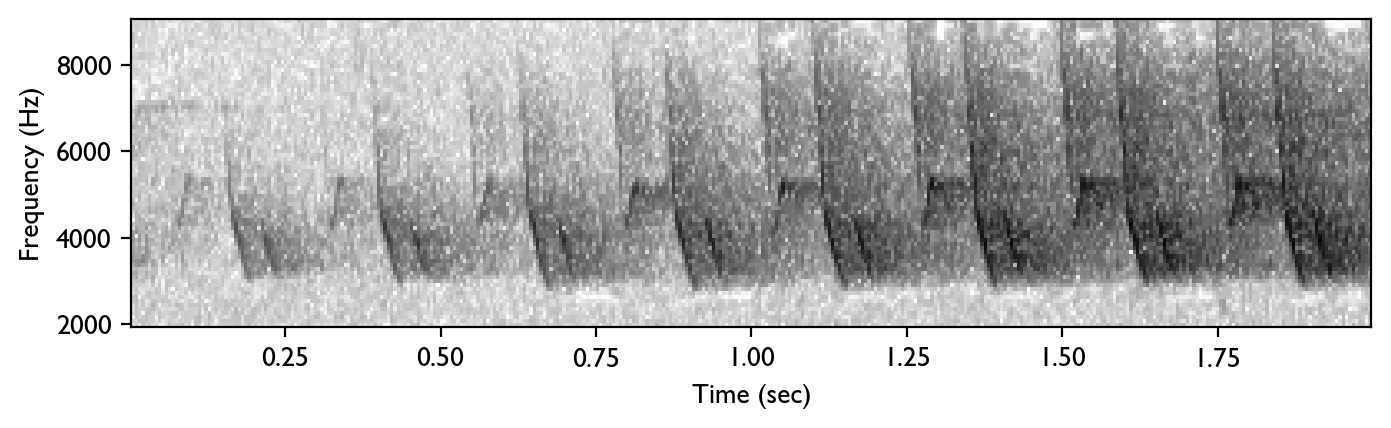

Individual ID: 20


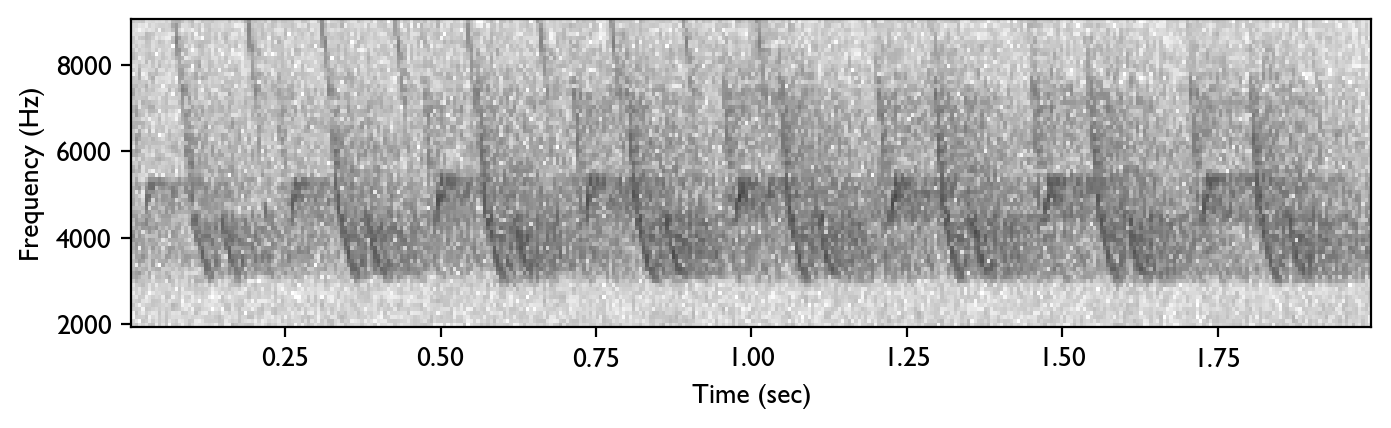

Individual ID: 20


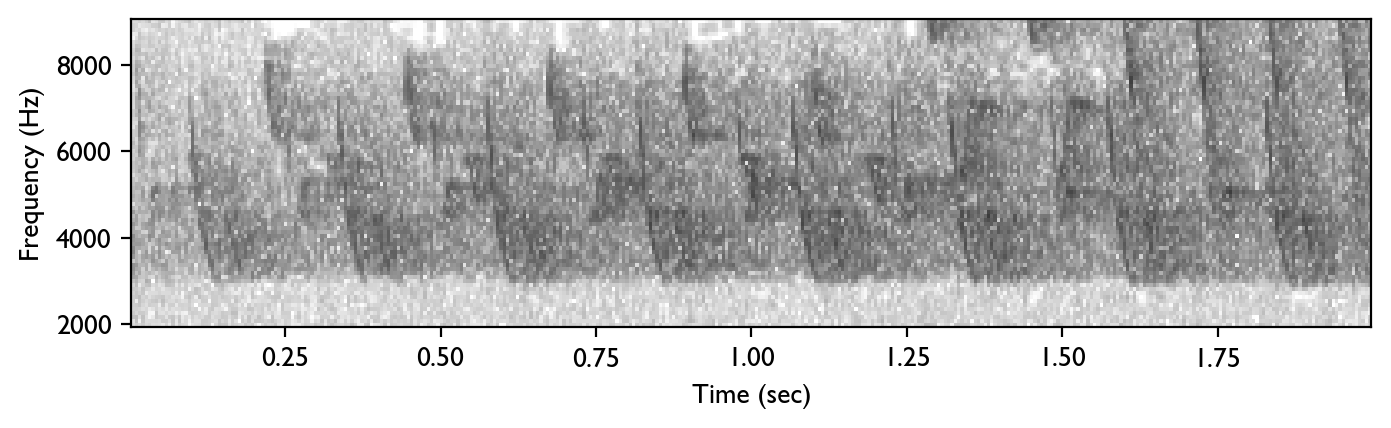

Individual ID: 3


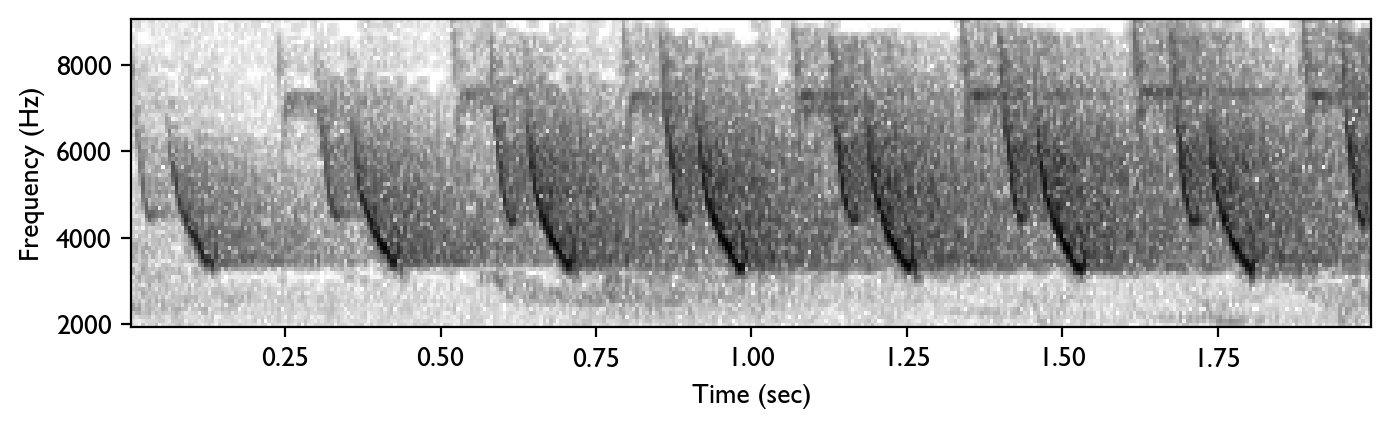

Individual ID: 3


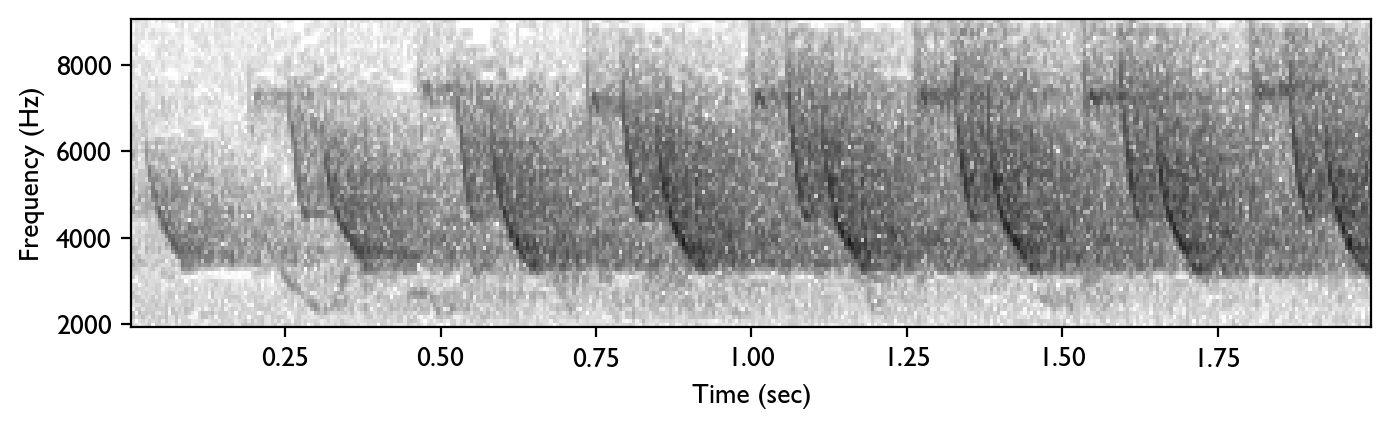

Individual ID: 3


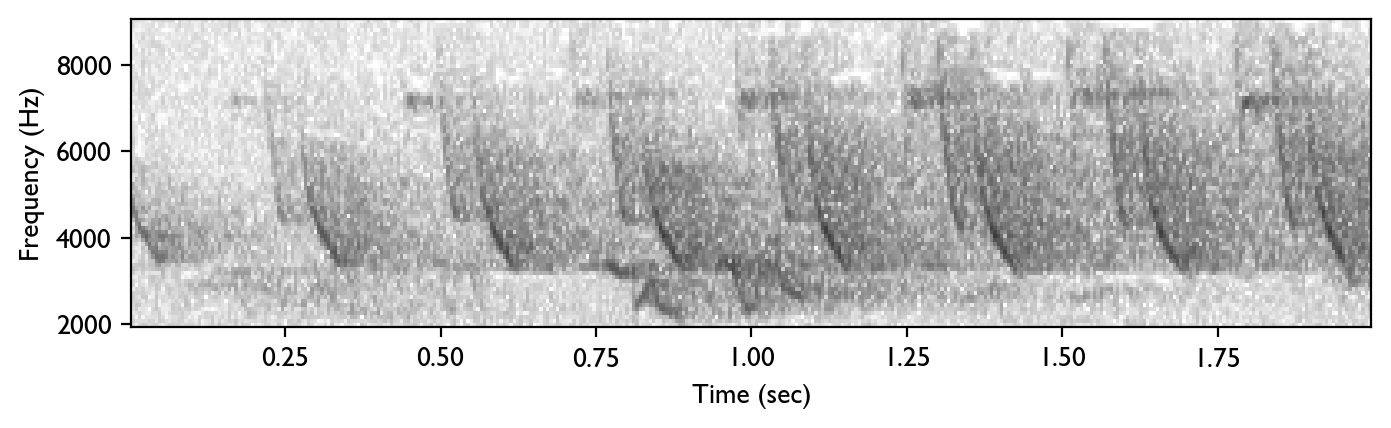

Individual ID: 21


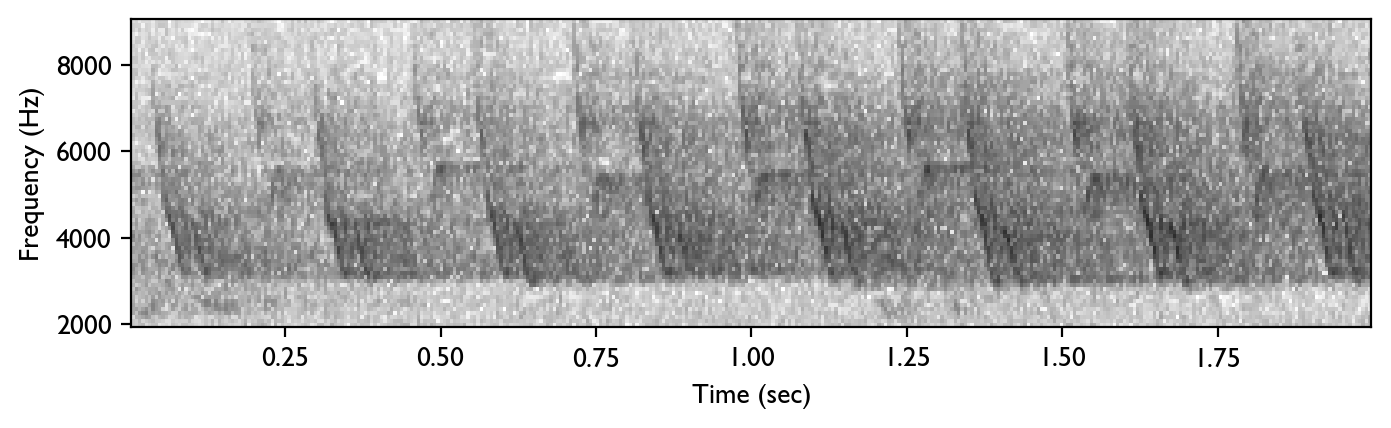

Individual ID: 21


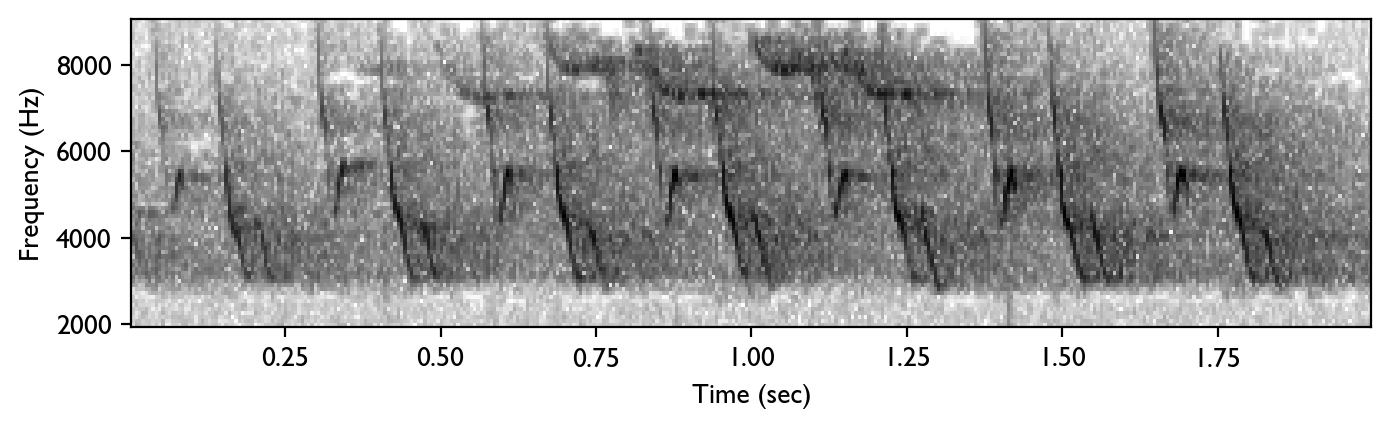

Individual ID: 21


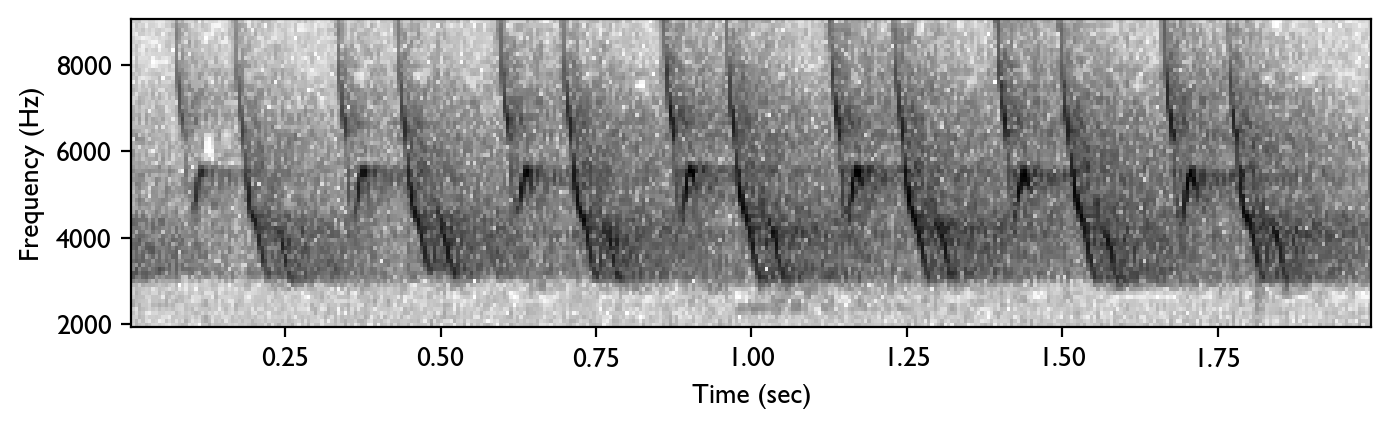

In [21]:
figsize(8, 2)
from opensoundscape import Audio, Spectrogram

for indv in list(audio_clip_table.aiid_label.unique())[0:3]:
    individual_clips = audio_clip_table[audio_clip_table.aiid_label == indv]
    for i in range(3):
        print(f"Individual ID: {individual_clips.iloc[i].aiid_label}")
        file = individual_clips.iloc[i].name[0]
        a = Audio.from_file(file).trim(4, 6)
        a.show_widget()  # intractive, playable audio display
        Spectrogram.from_audio(a).bandpass(2000, 9000).plot()  # plot spectrogram

For code and notebooks to reproduce analyses and figures from the manuscript, see the `scripts` folder and the README.md file.

We created the sample data of 100 songs from the full public labeled datset (available on [EDI](https://www.google.com/search?q=Environmental+Data+Initiative+edi.2049.1&rlz=1C5GCCM_en&oq=environm&gs_lcrp=EgZjaHJvbWUqBggAEEUYOzIGCAAQRRg7MgYIARBFGDkyBggCEEUYQTIGCAMQRRg8MgYIBBBFGD0yBggFEEUYPDIGCAYQRRhBMgYIBxBFGEHSAQg5OTUzajBqMagCALACAA&sourceid=chrome&ie=UTF-8)) using the code below:

In [ ]:
if False:
    # specify location of labeled dataset
    labels_dir = "./localization_dataset_labeled_clips"

    # read in the csv of audio clip annotations
    labels = pd.read_csv(f"{labels_dir}/labeled_clips.csv")
    iid_labels_with_most_entries = (
        labels.groupby("aiid_label")
        .localization_event_id.nunique()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    # sample 10 songs of 10 individuals for sample data in repo
    records = []
    for indv in iid_labels_with_most_entries:
        indv_samples = labels[labels.aiid_label == indv]
        indv_samples = indv_samples.drop_duplicates(subset="localization_event_id")
        indv_samples = indv_samples.sample(10, random_state=2024)
        records.append(indv_samples)

    label_subset = pd.concat(records)
    label_subset["song_center_time"] = 5
    label_subset["start_time"] = 4
    label_subset["end_time"] = 6

    import os

    dir = "./sample_data"
    audio_dir = f"{dir}/audio_clips"
    Path(audio_dir).mkdir(parents=True, exist_ok=False)

    label_subset["file"] = label_subset["clip_name"].apply(
        lambda f: f"./sample_data/audio_clips/{f}"
    )

    label_subset.drop(
        columns={
            "nearest_recorder",
            "aiid_label_sl",
            "notes_sl",
            "aiid_label_cc",
            "notes_cc",
            "rel_path",
            "folder",
        }
    ).to_csv(f"{dir}/labeled_clips_sample.csv", index=False)

    for f in label_subset.rel_path:
        # copy files to local folder
        os.system(f"cp {labels_dir}/{f} {audio_dir}/")